Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read datasets

In [3]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Response data cleaning steps

In [4]:
responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

responses["Response"] = (
    responses["Response"]
    .str.strip()
)

Merge datasets on Participant_ID

In [5]:
merged_data = responses.merge(
    metadata,
    on= "Participant_ID",
    how="left"
)

In [6]:
print(merged_data.shape)
print(merged_data.isnull().sum())

(336, 27)
Participant_ID     0
Focus              0
Agent_x            0
Goal_Type          0
Item               0
Item_string        0
Item_len           0
Response_tag      11
Response          11
EXP                0
n                  0
Age                0
Gender             0
Kno_Level          0
Per_Level          0
Bilingual          0
Bi_Parents         0
Multi_Kno          0
Multi_Spk          0
Immersion          0
Prof_Need          0
Prof_Use           0
Motivation         0
Agent_y            0
Distractor         0
GN_Score           0
Difficulty         0
dtype: int64


Verify Agent_x and Agent_y are identical

In [7]:
(merged_data["Agent_x"] == merged_data["Agent_y"]).all()

np.True_

Drop Agent_y and rename

In [8]:
merged_data = merged_data.drop(columns = ["Agent_y"])

merged_data = merged_data.rename(
    columns= {"Agent_x": "Agent"}
)

merged_data.shape

(336, 26)

In [9]:
merged_data.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,EXP,...,Bi_Parents,Multi_Kno,Multi_Spk,Immersion,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,1,...,1,0,1,0,1,1,4,4,23,3
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,1,...,1,0,1,0,1,1,4,4,23,3


In [10]:
merged_data.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'EXP', 'n', 'Age', 'Gender',
       'Kno_Level', 'Per_Level', 'Bilingual ', 'Bi_Parents', 'Multi_Kno',
       'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use', 'Motivation',
       'Distractor', 'GN_Score', 'Difficulty'],
      dtype='str')

Clean column names

In [11]:
merged_data.columns = merged_data.columns.str.strip()
metadata.columns = metadata.columns.str.strip()
responses.columns = responses.columns.str.strip()

In [12]:
merged_data.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'EXP', 'n', 'Age', 'Gender',
       'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents', 'Multi_Kno',
       'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use', 'Motivation',
       'Distractor', 'GN_Score', 'Difficulty'],
      dtype='str')

Level mapping labels

In [13]:
level_mapping = {
    1: "A1",
    2: "A2.1",
    3: "A2.2",
    4: "B1.1",
    5: "B1.2",
    6: "B2.1",
    7: "B2.2",
    8: "C1",
    9: "C2"
}

merged_data["Kno_Level_Label"] = (
    merged_data["Kno_Level"]
    .map(level_mapping)
)

In [14]:
merged_data["Kno_Level_Label"] = merged_data["Kno_Level"].map(level_mapping)
merged_data["Per_Level_Label"] = merged_data["Per_Level"].map(level_mapping)

In [15]:
merged_data.shape

(336, 28)

Order level labels

In [16]:
level_order = [
    "A1",
    "A2.1",
    "A2.2",
    "B1.1",
    "B1.2",
    "B2.1",
    "B2.2",
    "C1",
    "C2"
]

merged_data["Kno_Level_Label"] = pd.Categorical(
    merged_data["Kno_Level_Label"],
    categories=level_order,
    ordered=True
)

merged_data["Per_Level_Label"] = pd.Categorical(
    merged_data["Per_Level_Label"],
    categories=level_order,
    ordered=True
)

In [17]:
merged_data[["Kno_Level", "Kno_Level_Label", "Per_Level", "Per_Level_Label"]].tail(10)

,Kno_Level,Kno_Level_Label,Per_Level,Per_Level_Label
326,6,B2.1,5,B1.2
327,6,B2.1,5,B1.2
328,6,B2.1,5,B1.2
329,6,B2.1,5,B1.2
330,9,C2,8,C1
331,9,C2,8,C1
332,9,C2,8,C1
333,9,C2,8,C1
334,9,C2,8,C1
335,9,C2,8,C1


Counts and Proportions by Knowledge Level

In [18]:
pd.crosstab(
    merged_data["Kno_Level_Label"],
    merged_data["Response"]
)

Response,L1_transfer,L2_other,correct
Kno_Level_Label,,,
A1,4,0,2
B1.1,10,3,10
B1.2,1,5,0
B2.1,28,20,32
B2.2,41,22,24
C1,54,19,32
C2,11,3,4


In [19]:
kno_response_props = pd.crosstab(
    merged_data["Kno_Level_Label"],
    merged_data["Response"],
    normalize= "index",
    dropna=False
)

kno_response_props

Response,L1_transfer,L2_other,correct,NaN
Kno_Level_Label,,,,
A1,0.666667,0.000000,0.333333,0.0
A2.1,0.000000,0.000000,0.000000,0.0
A2.2,0.000000,0.000000,0.000000,0.0
B1.1,0.434783,0.130435,0.434783,0.0
B1.2,0.166667,0.833333,0.000000,0.0
B2.1,0.350000,0.250000,0.400000,0.0
B2.2,0.471264,0.252874,0.275862,0.0
C1,0.514286,0.180952,0.304762,0.0
C2,0.611111,0.166667,0.222222,0.0


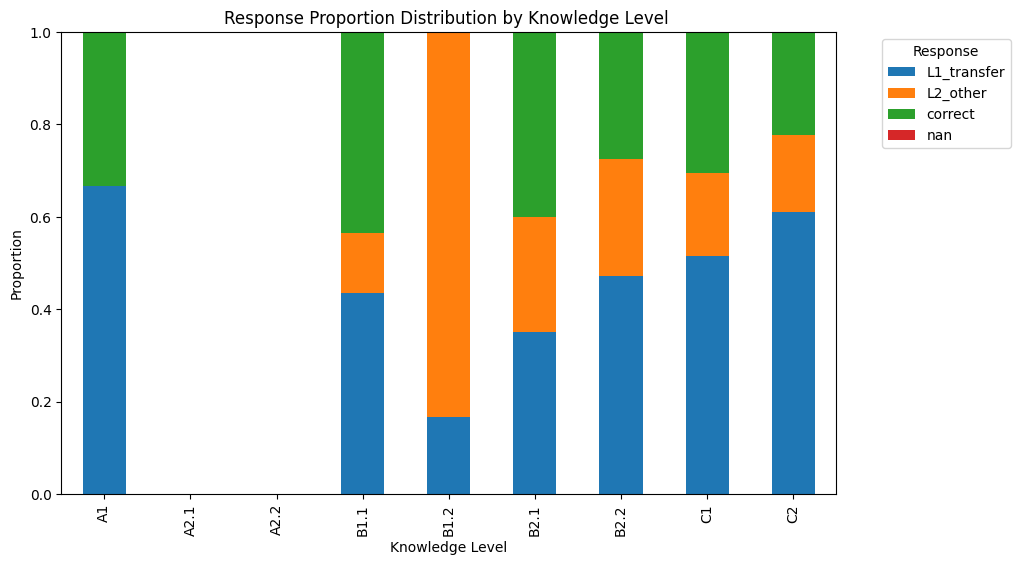

In [20]:
kno_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Knowledge Level ")
plt.xlabel("Knowledge Level")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Counts and Proportions Perceived Level

In [21]:
pd.crosstab(
    merged_data["Per_Level_Label"],
    merged_data["Response"]
)

Response,L1_transfer,L2_other,correct
Per_Level_Label,,,
B1.2,7,11,19
B2.1,28,16,22
B2.2,81,35,45
C1,33,9,15
C2,0,1,3


In [22]:
per_response_props = pd.crosstab(
    merged_data["Per_Level_Label"],
    merged_data["Response"],
    normalize= "index",
    dropna=False
)

per_response_props

Response,L1_transfer,L2_other,correct,NaN
Per_Level_Label,,,,
A1,0.000000,0.000000,0.000000,0.0
A2.1,0.000000,0.000000,0.000000,0.0
A2.2,0.000000,0.000000,0.000000,0.0
B1.1,0.000000,0.000000,0.000000,0.0
B1.2,0.189189,0.297297,0.513514,0.0
B2.1,0.424242,0.242424,0.333333,0.0
B2.2,0.503106,0.217391,0.279503,0.0
C1,0.578947,0.157895,0.263158,0.0
C2,0.000000,0.250000,0.750000,0.0


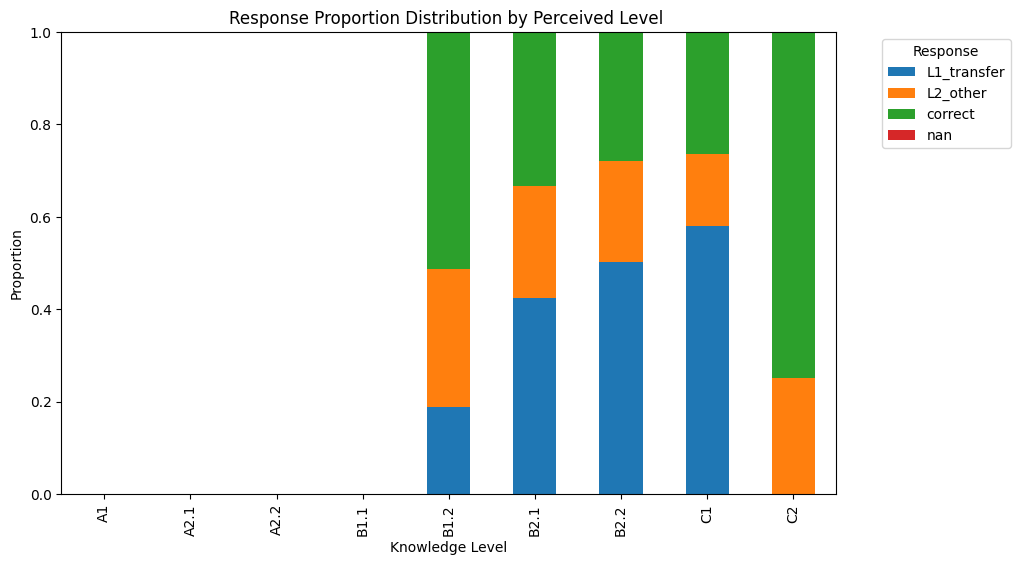

In [23]:
per_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Perceived Level ")
plt.xlabel("Knowledge Level")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()